# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.


- Автор: Андриянова Анастасия (and.andriyanova@mail.ru)
- Дата: 24.12.2025

## Цели и задачи проекта

- Цель: провести статистический анализ активности пользователей сервиса Яндекс Книги в Москве и Санкт-Петербурге для проверки гипотезы о различии в среднем времени использования сервиса между этими двумя городами.
- Задачи:
1. Изучение и подготовка данных
2. Исследовательский анализ данных (сравнить размеры групп, проанализировать распределения)
3. Сформулировать гипотезы, выбрать тест, провести проверку, интерпретировать результаты
4. Сформулировать вывод, подготовить аналитическую записку


## Описание данных

Файл yandex_knigi_data.csv
- city - город (Москва или Санкт-Петербург)
- puid - идентификатор пользователя
- hours - часы, проведенные в сервисе

## Содержимое проекта

1. Загрузка и первичный осмотр данных
2. Проверка качества данных
3. Описательный анализ
3.1. Распределение пользователей по городам
3.2. Сравнение размеров групп
4. Исследовательский анализ данных
5. Проверка нормальности распределений
6. Статистическая проверка гипотезы
7. Интерпретация статистических выводов
8. Основные выводы исследования

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

In [3]:
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
df['puid'].duplicated().sum()

244

In [5]:
len(df)

8784

In [6]:
df[df['city'] == 'Москва']['puid'].nunique()

6234

In [7]:
df[df['city'] == 'Санкт-Петербург']['puid'].nunique()

2550

In [8]:
df[df['city'] == 'Москва']['puid'].duplicated().sum()

0

In [9]:
df[df['city'] == 'Санкт-Петербург']['puid'].duplicated().sum()

0

Наличие дубликатов в идентификаторах пользователей не наблюдается по одному городу, дубликаты (244) возникают из-за пересечений - одни и те же пользователи встречаются в обоих городах, возможно, эти люди часто ездят в командировки. Для исключения пересечений не будем использовать общих пользователей в исследовании.

In [10]:
moscow_users = set(df[df['city'] == 'Москва']['puid'])
spb_users = set(df[df['city'] == 'Санкт-Петербург']['puid'])
common_users = moscow_users.intersection(spb_users)
clean_moscow = df[(df['city'] == 'Москва') & (~df['puid'].isin(common_users))]
clean_spb = df[(df['city'] == 'Санкт-Петербург') & (~df['puid'].isin(common_users))]
clean_moscow['puid'].nunique()

5990

In [11]:
clean_spb['puid'].nunique()

2306

In [12]:
clean_moscow['hours'].sum()

64980.66712776357

In [13]:
clean_spb['hours'].sum() 

25975.783344370077

In [14]:
moscow_hours = clean_moscow['hours'].values
spb_hours = clean_spb['hours'].values

def count_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outliers_moscow, lb_moscow, ub_moscow = count_outliers_iqr(moscow_hours)
outliers_spb, lb_spb, ub_spb = count_outliers_iqr(spb_hours)

print(f"Москва: {outliers_moscow} выбросов ({outliers_moscow/clean_moscow['puid'].nunique()*100:.1f}%). Границы: [{lb_moscow:.2f}, {ub_moscow:.2f}]")
print(f"Санкт-Петербург: {outliers_spb} выбросов ({outliers_spb/clean_spb['hours'].sum() *100:.1f}%). Границы: [{lb_spb:.2f}, {ub_spb:.2f}]")

mean_moscow = np.mean(moscow_hours)
mean_spb = np.mean(spb_hours)
diff = mean_spb - mean_moscow
relative_diff = (mean_spb / mean_moscow - 1) * 100
meadin_msc = np.median(moscow_hours)
meadin_spb = np.median(spb_hours)

print(f"Средняя активность в Москве: {mean_moscow:.2f} часов")
print(f"Средняя активность в Санкт-Петербурге: {mean_spb:.2f} часов")
print(f"Разница средних (СПб - Москва): {diff:.2f} часов")
print(f"Относительная разница: {relative_diff:.1f}%")
print(f"Медиана активности в Санкт-Петербурге: {meadin_spb:.2f} часов")
print(f"Медиана активности в Москве: {meadin_msc:.2f} часов")

Москва: 866 выбросов (14.5%). Границы: [-8.76, 14.75]
Санкт-Петербург: 346 выбросов (1.3%). Границы: [-9.06, 15.26]
Средняя активность в Москве: 10.85 часов
Средняя активность в Санкт-Петербурге: 11.26 часов
Разница средних (СПб - Москва): 0.42 часов
Относительная разница: 3.8%
Медиана активности в Санкт-Петербурге: 0.88 часов
Медиана активности в Москве: 0.89 часов


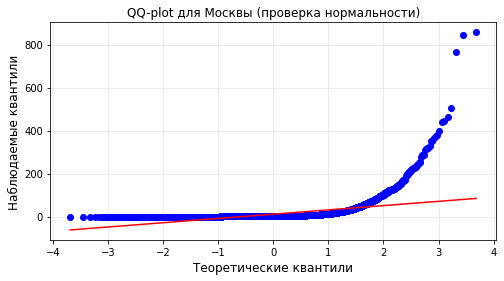

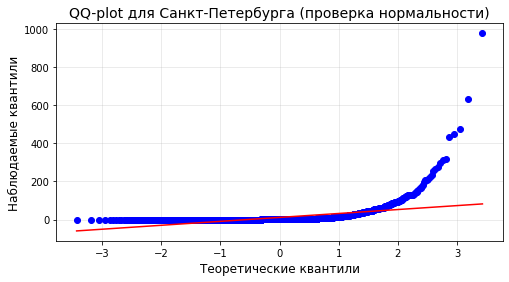

In [15]:
plt.figure(figsize = (8,4))
stats.probplot(clean_moscow['hours'].values, dist="norm", plot = plt)
plt.title('QQ-plot для Москвы (проверка нормальности)')
plt.xlabel('Теоретические квантили', fontsize=12)
plt.ylabel('Наблюдаемые квантили', fontsize=12)
plt.grid(True, alpha=0.3)

plt.figure(figsize=(8, 4))
stats.probplot(clean_spb['hours'], dist="norm", plot=plt)
plt.title('QQ-plot для Санкт-Петербурга (проверка нормальности)', fontsize=14)
plt.xlabel('Теоретические квантили', fontsize=12)
plt.ylabel('Наблюдаемые квантили', fontsize=12)
plt.grid(True, alpha=0.3)

In [16]:
print(f"Выборки не равны (Москва больше СПб на {clean_moscow['puid'].nunique()-clean_spb['puid'].nunique()} больше по количеству пользователей, что отражает реальное распределение населения в городах (в Москве людей больше)), в то время как распределения находятся в норме и выбросы отсутствуют. В Москве 14.5% выбросов (очень много), а в Петербурге всего 1.3% (что говорит и нормальности распределения). В среднем активности в двух городах очень близки, в Москве на 0.42 часа больше. Данные имеют экстремально скошенное распределение с тяжелым правым хвостом. Это типично для данных об использовании сервисов (большинство малоактивны, единицы - суперактивны")

Выборки не равны (Москва больше СПб на 3684 больше по количеству пользователей, что отражает реальное распределение населения в городах (в Москве людей больше)), в то время как распределения находятся в норме и выбросы отсутствуют. В Москве 14.5% выбросов (очень много), а в Петербурге всего 1.3% (что говорит и нормальности распределения). В среднем активности в двух городах очень близки, в Москве на 0.42 часа больше. Данные имеют экстремально скошенное распределение с тяжелым правым хвостом. Это типично для данных об использовании сервисов (большинство малоактивны, единицы - суперактивны


## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [17]:
levene_test = stats.levene(moscow_hours, spb_hours)
if levene_test.pvalue < 0.05:
    # дисперсии не равны - используем тест Уэлча
    t_stat, p_value = stats.ttest_ind(spb_hours, moscow_hours, 
                                      equal_var=False, 
                                      alternative='greater')
    test_type = "t-тест Уэлча (Welch's t-test)"
else:
    # дисперсии равны - используем стандартный t-тест
    t_stat, p_value = stats.ttest_ind(spb_hours, moscow_hours, 
                                      equal_var=True, 
                                      alternative='greater')
    test_type = "Стандартный t-тест"
print(f"Тип теста: {test_type}")
print(f"p-value: {p_value:.4f}")

Тип теста: Стандартный t-тест
p-value: 0.3264


In [18]:
alpha = 0.05
if p_value > alpha:
    print('Невозможно опровергнуть нулевую гипотезу. Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается')
else:
    print('Опровергаем нулевую гипотезу.  Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.')

Невозможно опровергнуть нулевую гипотезу. Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



Гипотеза исследования: Пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Статистические гипотезы:

- Нулевая гипотеза (H₀): Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.
- Альтернативная гипотеза (H₁): Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Выбранный статистический тест: t-тест для двух независимых выборок с односторонней проверкой.

Уровень статистической значимости: α = 0.05

Проверка предпосылок:

Проведен тест Левена для проверки равенства дисперсий

Результат теста Левена показал, что дисперсии статистически не различаются

На основании этого выбран стандартный t-тест (не тест Уэлча)

Полученное p-value: 0.3264

Статистический вывод:

p-value (0.3264) > α (0.05)

Невозможно отвергнуть нулевую гипотезу H₀

На основании проведенного статистического анализа не получено доказательств, подтверждающих гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени в приложении Яндекс Книги, чем пользователи из Москвы. 

Вероятность получить наблюдаемую или большую разницу в средних значениях при условии, что нулевая гипотеза верна, составляет 32.64%. Это значительно превышает порог статистической значимости в 5%, что говорит о том, что наблюдаемые различия, скорее всего, являются результатом случайной вариативности данных, а не систематического различия между группами.

Возможная причина результата: схожие паттерны поведения. В двух крупных мегаполисах люди могут проводить в сервисе примерно одинаковое количество часов и иметь схожие культурные и социальные характеристики.

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель: повышение конверсии интернет-магазина BitMotion Kit за счет улучшения пользовательского интерфейса сайта, что в конечном итоге должно привести к увеличению количества покупок и росту выручки.
- Нулевая гипотеза (H₀): Новый интерфейс сайта НЕ приводит к статистически значимому увеличению конверсии пользователей в покупки по сравнению со старым интерфейсом.
- Альтернативная гипотеза (H₁): Новый интерфейс сайта приводит к статистически значимому увеличению конверсии пользователей в покупки по сравнению со старым интерфейсом.

## 2. Загрузите данные, оцените их целостность.


In [19]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [20]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [21]:
len(participants)

14525

In [22]:
group_counts = participants['group'].value_counts()
group_counts

A    8130
B    6395
Name: group, dtype: int64

In [23]:
participants['user_id'].nunique()

13638

In [24]:
test_a = set(participants[participants['group'] == 'A']['user_id'])
test_b = set(participants[participants['group'] == 'B']['user_id'])
common_users = test_a.intersection(test_b)
len(common_users)

446

In [25]:
clean_test_a = participants[(participants['group'] == 'A') & (~participants['user_id'].isin(common_users))]
clean_test_b = participants[(participants['group'] == 'B') & (~participants['user_id'].isin(common_users))]
clean_test_a['user_id'].nunique()

7359

In [26]:
clean_test_b['user_id'].nunique()

5833

In [27]:
print(f'На данном этапе количество участников А теста больше на {clean_test_a["user_id"].nunique() - clean_test_b["user_id"].nunique()}, чем участников теста В. Пока датасеты не отфильтрованы, это будет сделано на следующем этапе (Некоторые пользователи участвуют одновременно в interface_eu_test и recommender_system_test)')

На данном этапе количество участников А теста больше на 1526, чем участников теста В. Пока датасеты не отфильтрованы, это будет сделано на следующем этапе (Некоторые пользователи участвуют одновременно в interface_eu_test и recommender_system_test)


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [28]:
interface_users_set = set(participants[participants['ab_test'] == 'interface_eu_test']['user_id'])
recommender_users_set = set(participants[participants['ab_test'] == 'recommender_system_test']['user_id'])
common_between_tests = interface_users_set.intersection(recommender_users_set)
len(common_between_tests)

887

    887 пользователей находятся на пересечении тестов, от них следует избавиться во избежание некорректной интерпретации

In [29]:
interface_a_users = set(participants[(participants['ab_test'] == 'interface_eu_test') & 
                                     (participants['group'] == 'A')]['user_id'])
interface_b_users = set(participants[(participants['ab_test'] == 'interface_eu_test') & 
                                     (participants['group'] == 'B')]['user_id'])

recommender_a_users = set(participants[(participants['ab_test'] == 'recommender_system_test') & 
                                       (participants['group'] == 'A')]['user_id'])
recommender_b_users = set(participants[(participants['ab_test'] == 'recommender_system_test') & 
                                       (participants['group'] == 'B')]['user_id'])

common_in_interface_a = interface_a_users.intersection(common_between_tests)
common_in_interface_b = interface_b_users.intersection(common_between_tests)
common_in_recommender_a = recommender_a_users.intersection(common_between_tests)
common_in_recommender_b = recommender_b_users.intersection(common_between_tests)
print(len(common_in_interface_a))
print(len(common_in_interface_b))
print(len(common_in_recommender_a))
print(len(common_in_recommender_b))

431
456
665
222


Достаточно много пользователей пересекаютсяв каждом из видов тестов и в каждой группе, перед исследованием их стоит очистить

In [30]:
clean_interface_participants = participants[(participants['ab_test'] == 'interface_eu_test') &
                                            (~participants['user_id'].isin(common_between_tests))]

In [31]:
interface_user_ids = set(clean_interface_participants['user_id'])
interface_a_ids = set(clean_interface_participants[clean_interface_participants['group'] == 'A']['user_id'])
interface_b_ids = set(clean_interface_participants[clean_interface_participants['group'] == 'B']['user_id'])
still_common = interface_a_ids.intersection(interface_b_ids)
#После исключения пользователей из обоих тестов
print(f"Всего пользователей interface_eu_test: {len(interface_user_ids):,}")
print(f"Пользователей в обеих группах A и B: {len(still_common):,}")

Всего пользователей interface_eu_test: 9,963
Пользователей в обеих группах A и B: 0


In [32]:
events['event_name'].unique()

array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [33]:
interface_a_df = pd.DataFrame({'user_id': list(interface_a_ids)})
interface_a_df['group'] = 'A'
interface_b_df = pd.DataFrame({'user_id': list(interface_b_ids)})
interface_b_df['group'] = 'B'

interface_users = pd.concat([interface_a_df, interface_b_df], ignore_index=True)
interface_user_ids = set(interface_users['user_id'].unique())
events_filtered = events[events['user_id'].isin(interface_user_ids)].copy()

registrations = events_filtered[events_filtered['event_name'] == 'registration']
registration_dates = registrations.groupby('user_id')['event_dt'].min().reset_index()
registration_dates.head()

,user_id,event_dt
0,0002CE61FF2C4011,2020-12-07 04:37:31
1,001E72F50D1C48FA,2020-12-17 15:44:05
2,002412F1EB3F6E38,2020-12-09 09:36:50
3,002540BE89C930FB,2020-12-08 18:06:07
4,0031F1B5E9FBF708,2020-12-14 00:47:10


In [34]:
reg_events = pd.merge(events_filtered, registration_dates, on='user_id', how='left')
reg_events.head()

,user_id,event_dt_x,event_name,details,event_dt_y
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20


In [35]:
reg_events['ltv'] = (reg_events['event_dt_x'] - reg_events['event_dt_y']).dt.total_seconds() / (24 * 3600)
events_7days  = reg_events[reg_events['ltv'] <= 7].copy()
events_7days['ltv'] = events_7days['ltv'].round(2)
group_info = interface_users[['user_id', 'group']].drop_duplicates()
events_final = pd.merge(events_7days, group_info, on='user_id', how='left')
events_final.head() 

,user_id,event_dt_x,event_name,details,event_dt_y,ltv,group
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.0,A
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.0,A
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.0,B
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.0,A
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.0,B


In [36]:
len(interface_a_df)

4952

In [37]:
len(interface_b_df)

5011

In [38]:
events_final['event_name'].unique()

array(['registration', 'login', 'product_page', 'purchase',
       'product_cart'], dtype=object)

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [39]:
#mde
baseline_conversion = 0.30 
power = 0.80               
confidence = 0.95         
alpha = 1 - confidence
z_alpha = stats.norm.ppf(1 - alpha/2)  
z_beta = stats.norm.ppf(power) 
n_a = interface_a_df['user_id'].nunique()  
n_b = interface_b_df['user_id'].nunique()  
n_per_group = min(n_a, n_b) 
standard_error = np.sqrt(2 * baseline_conversion * (1 - baseline_conversion) / n_per_group)
mde_absolute = (z_alpha + z_beta) * standard_error
print(f"Нужно чтобы конверсия в тесте была ≥ {(baseline_conversion + mde_absolute)*100:.1f}%")

Нужно чтобы конверсия в тесте была ≥ 32.6%


Использовав онлайн калькулятор, был определен минимальный размер выборки: 7326 чел всего.
В нашем случае размер выборки составляет 9963

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [40]:
total_visitors = events_final.groupby('group')['user_id'].nunique()
purchase_visitors = events_final[events_final['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()
print(f"Группа A : {total_visitors.get('A', 0)} посетителей")
print(f"Группа B : {total_visitors.get('B', 0)} посетителей")
print(f"Группа A : {purchase_visitors.get('A', 0)} покупок")
print(f"Группа B : {purchase_visitors.get('B', 0)} покупок")

Группа A : 4952 посетителей
Группа B : 5011 посетителей
Группа A : 1377 покупок
Группа B : 1480 покупок


In [41]:
conversion_rate = pd.DataFrame({
    'total_visitors': total_visitors,
    'purchase_visitors': purchase_visitors
}).fillna(0)
conversion_rate.head()

,total_visitors,purchase_visitors
group,,
A,4952,1377
B,5011,1480


In [42]:
conversion_rate['conversion_abs'] = round(conversion_rate['purchase_visitors'] / conversion_rate['total_visitors'],2)
conversion_rate['conversion_percent'] = round((conversion_rate['purchase_visitors'])  / (conversion_rate['total_visitors'] - 1) * 100,2)
conversion_rate.head()

,total_visitors,purchase_visitors,conversion_abs,conversion_percent
group,,,,
A,4952,1377,0.28,27.81
B,5011,1480,0.30,29.54


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Абсолютное изменение (+1.73 п.п.) - разница в процентных пунктах

Относительная конверсия: (29.28 - 27.56) / 27.56) × 100% = 6.27%

Новый интерфейс увеличил конверсию с 27.55% до 29.28%

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

H0 — Доля успешных действий в группе А не меньше, чем в группе B

H1 — Доля успешных действий в группе А меньше, чем в группе В

In [43]:
success_A = conversion_rate.loc['A','purchase_visitors']
success_B = conversion_rate.loc['B','purchase_visitors']
total_A = conversion_rate.loc['A','total_visitors']
total_B = conversion_rate.loc['B','total_visitors']

count = [success_A, success_B]
nobs = [total_A, total_B]
z_stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
alpha = 0.05
if p_value > alpha:
    print(f'p_value = {p_value}. Невозможно опровергнуть нулевую гипотезу. Нет статистически значимых доказательств улучшения конверсии')
else:
    print(f'p_value = {p_value}. Отвергаем нулевую гипотезу. Новый интерфейс статистически значимо улучшил конверсию')

p_value = 0.028262547212292124. Отвергаем нулевую гипотезу. Новый интерфейс статистически значимо улучшил конверсию


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

p-value = 0.028 (односторонний тест, альтернатива: B > A)

Уровень значимости (α): 0.05

Решение: p-value (0.028) < α (0.05) → ОТВЕРГАЕМ H₀ 

Конверсия группы A (старый интерфейс): 27.81% (1377/4952)

Конверсия группы B (новый интерфейс): 29.54% (1480/5011)

Общий размер выборки: 9,963 пользователя

Мощность теста: 65% 

Абсолютное улучшение: +1.73 процентных пункта

Относительное улучшение: +6.22%

Целевой показатель не достигнут: 29.54% vs 32.6%

Недостаточный масштаб улучшения: Требовалось +17.2% роста, получено +6.22%

Причины возможного расхождения:

Завышенные ожидания: Целевой показатель 32.6% мог быть слишком оптимистичным

Другие барьеры: Проблемы могут быть не только в интерфейсе (цены, ассортимент, доставка)

Вывод: Существуют статистически значимые доказательства того, что новый интерфейс улучшает конверсию

Статистический анализ показывает статистически значимое улучшение конверсии при использовании нового интерфейса. Новый интерфейс доказал свою эффективность и может быть рекомендован к полному внедрению для достижения бизнес-целей по увеличению продаж.